# SEA: Segment, Embed, and Align
## Complete End-to-End Subtitle Alignment Walkthrough — Minute-Level Detail

**Paper:** *Segment, Embed, and Align: A Universal Recipe for Aligning Subtitles to Signing*  
Zifan Jiang, Youngjoon Jang, Liliane Momeni, Gül Varol, Sarah Ebling, Andrew Zisserman (2025)  
[arXiv:2512.08094](https://arxiv.org/abs/2512.08094)

---

### The Core Problem This Notebook Solves

When a sign language video is produced, its subtitles are typically generated from the **spoken audio track** — either by a human interpreter or automatic speech recognition. This means every subtitle timestamp reflects when the word was *spoken*, not when it was *signed*.

Signing lags behind speech by a variable delay (often 2–5 seconds) due to interpretation lag, the slower articulation rate of sign language, and grammatical reordering. The result is subtitles that appear **seconds before or after** the signing they describe.

**SEA corrects this** by treating alignment as an optimisation problem: given a sequence of subtitle cues $\{c_1, c_2, \ldots, c_M\}$ and a sequence of sign-language segments $\{s_1, s_2, \ldots, s_N\}$, find the mapping that minimises total temporal mismatch.

---

### Key Terminology

| Term | Precise Definition |
|------|-------------------|
| **Alignment** | The operation of replacing a subtitle cue's `(start, end)` timestamps with new values that correspond to when that subtitle's content is actually being signed. The *text* is never modified. |
| **Gloss / Gloss Label** | A written token that represents a single sign gesture, transcribed using a spoken-language word or phrase that approximates the sign's meaning. Example: `สวัสดี` (hello), `(ผายมือ)` (open-hand wave). Each gloss is time-stamped at sub-second precision. |
| **ELAN / EAF** | ELAN (EUDICO Linguistic Annotator) is the industry-standard tool for multimodal corpus annotation. EAF (ELAN Annotation Format) files are XML documents storing multiple overlapping time-aligned annotation layers (*tiers*) over the same video. |
| **Cue** | One subtitle segment: a `(start, end, text)` triple representing a sentence-length unit of spoken/signed content. |
| **Sign segment** | A single sign gesture with a precise temporal boundary — the smallest unit used as an anchor in the DP alignment. |
| **DP (Dynamic Programming)** | A class of algorithms that solve optimisation problems by breaking them into overlapping sub-problems and caching intermediate results. Here, DP finds the globally optimal alignment in O(M × N) time (with windowing). |

---

### What This Notebook Covers

| Section | Content | Key SEA File |
|---------|---------|-------------|
| 1 | Environment & path setup | — |
| 2 | Loading and inspecting the ELAN annotation file | `utils.py` |
| 3 | Extracting subtitle cues and sign-segment anchors | `utils.py` |
| 4 | Numba JIT warmup | `align_dp.py` |
| 5 | Running the DP alignment algorithm | `align_dp.py` |
| 6 | Writing the output EAF and WebVTT files | `utils.py` |
| 7 | Quantitative evaluation + metric visualisation | `misc/evaluate_sub_alignment.py` |
| 8 | Timeline visualisation | matplotlib |

> **Prerequisites:** Run `uv sync` from the repository root and activate `.venv` before starting the Jupyter kernel.

---
## Section 1 — Environment & Path Setup

### 1.1 — How Python Finds Modules: `sys.path` in Depth

When you write `import align_dp`, Python searches **in order** through every directory listed in `sys.path`. If none of them contains a file called `align_dp.py` (or a package directory `align_dp/`), you get an `ImportError`.

By default, a Jupyter kernel launched from `notebooks/` has a `sys.path` that includes:
- The kernel's site-packages (our `.venv/Lib/site-packages/`)
- The current working directory (`notebooks/`)

It does **not** include `SEA/` or `SEA/misc/`. We must add them manually.

**Why `SEA/misc/` too?**  
`align_dp.py` contains the line `from align_dp_visualization import visualize_similarity_heatmap` at module import time. This bare import (no package prefix) only resolves if `SEA/` is on `sys.path`. Similarly, `misc/evaluate_sub_alignment.py` uses bare imports from the same directory. Adding `SEA/misc/` lets us do `from evaluate_sub_alignment import eval_subtitle_alignment` directly.

**Why `sys.path.insert(0, ...)` and not `.append(...)`?**  
Using index 0 makes our local `SEA/` modules take priority over any identically-named packages that might be installed in site-packages. This prevents shadowing bugs.

**`Path.cwd().parent` vs `__file__`**  
In a `.py` script, `__file__` is reliable. In a Jupyter notebook, `__file__` is undefined. `Path.cwd()` returns the directory from which the Jupyter kernel was launched — which is `notebooks/` when started via `cd notebooks && jupyter notebook`. Taking `.parent` gives us the repository root.

In [1]:
import sys
import os
from pathlib import Path

# The Jupyter kernel is launched from notebooks/, so cwd() is notebooks/.
# .parent steps up one level to the repository root.
REPO_ROOT = Path(os.getcwd()).parent

# SEA/ contains all core algorithm files (align_dp.py, utils.py, etc.).
SEA_DIR  = REPO_ROOT / "SEA"

# SEA/misc/ contains evaluate_sub_alignment.py.
MISC_DIR = SEA_DIR / "misc"

# data/example_alignment/ holds the Thai Sign Language demo dataset.
DATA_DIR = REPO_ROOT / "data" / "example_alignment"

# assets/ is where we save publication-quality figures.
ASSETS_DIR = REPO_ROOT / "assets"
ASSETS_DIR.mkdir(exist_ok=True)

# Add to front of sys.path so local modules shadow any installed packages.
for p in [str(SEA_DIR), str(MISC_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Sanity checks — fail loudly if paths are wrong.
assert REPO_ROOT.exists(),  f"Repo root not found: {REPO_ROOT}"
assert SEA_DIR.exists(),    f"SEA source dir not found: {SEA_DIR}"
assert DATA_DIR.exists(),   f"Data dir not found: {DATA_DIR}"

print(f"Repository root  : {REPO_ROOT}")
print(f"SEA source dir   : {SEA_DIR}")
print(f"Example data dir : {DATA_DIR}")
print(f"Assets output dir: {ASSETS_DIR}")
print(f"\nsys.path (first 3 entries):")
for p in sys.path[:3]:
    print(f"  {p}")

Repository root  : c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub
SEA source dir   : c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\SEA
Example data dir : c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment
Assets output dir: c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\assets

sys.path (first 3 entries):
  c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\SEA\misc
  c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\SEA
  C:\Users\USER\AppData\Roaming\uv\python\cpython-3.12.12-windows-x86_64-none\python312.zip


### 1.2 — CUDA Device Detection: What Happens Under the Hood

**Why we check for a GPU at all:**  
The SEA pipeline has two compute-intensive phases:
1. **DP alignment** (`align_dp.py`) — runs entirely on CPU via numba-compiled C code. No GPU needed or used, regardless of what's available.
2. **Embedding** (`align_similarity.py`) — if `similarity_measure=sign_clip_embedding` or `text_embedding`, PyTorch models are loaded and run inference. This benefits massively from a CUDA GPU.

This notebook runs Phase 1 only (no embeddings), so the GPU won't be used. But we detect it here so that any optional embedding extension cells below can reference `DEVICE` without repeating the detection.

**What `torch.cuda.is_available()` actually checks:**  
1. Was PyTorch compiled with CUDA support? (Our `torch==2.6.0` wheel from PyPI is.)
2. Is a CUDA-capable NVIDIA GPU present in the system?
3. Is a compatible CUDA driver installed (≥ the CUDA toolkit version PyTorch was compiled with)?

All three must be true. If your GPU is detected but CUDA isn't available, the driver version is almost always the culprit.

**`torch.device` vs a plain string:**  
`torch.device('cuda')` is a typed object. Passing it to `model.to(DEVICE)` or `tensor.to(DEVICE)` is identical to passing the string `'cuda'`, but the typed object gives better error messages and is preferred by type checkers.

In [2]:
import torch

# Standard device-agnostic setup used throughout PyTorch codebases.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version  : {torch.__version__}")
print(f"Active device    : {DEVICE}")

if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU model        : {props.name}")
    print(f"VRAM total       : {props.total_memory / 1e9:.1f} GB")
    print(f"CUDA capability  : {props.major}.{props.minor}")
    print(f"Multiprocessors  : {props.multi_processor_count}")
else:
    print("No CUDA GPU detected.")
    print("DP alignment runs entirely on CPU via numba — this is fully supported and normal.")

PyTorch version  : 2.6.0+cpu
Active device    : cpu
No CUDA GPU detected.
DP alignment runs entirely on CPU via numba — this is fully supported and normal.


---
## Section 2 — Load and Inspect the ELAN Annotation File

### 2.1 — The ELAN XML Schema and the Thai Filename Challenge

**ELAN file structure (abridged):**
```xml
<ANNOTATION_DOCUMENT>
  <HEADER>
    <MEDIA_DESCRIPTOR MEDIA_URL="04.mp4" MIME_TYPE="video/mp4"/>
  </HEADER>

  <!-- TIME_ORDER: the global clock. Every annotation references two TIME_SLOTs. -->
  <TIME_ORDER>
    <TIME_SLOT TIME_SLOT_ID="ts1" TIME_VALUE="40"/>   <!-- 40 ms -->
    <TIME_SLOT TIME_SLOT_ID="ts2" TIME_VALUE="31890"/> <!-- 31.89 s -->
    ...
  </TIME_ORDER>

  <!-- Each TIER is one annotation layer (e.g. CC, Gloss Labeling, ...). -->
  <TIER TIER_ID="CC" LINGUISTIC_TYPE_REF="imported-sub">
    <ANNOTATION>
      <ALIGNABLE_ANNOTATION ANNOTATION_ID="a1"
                            TIME_SLOT_REF1="ts1"   <!-- references TIME_ORDER -->
                            TIME_SLOT_REF2="ts2">
        <ANNOTATION_VALUE>[เสียงดนตรี]</ANNOTATION_VALUE>
      </ALIGNABLE_ANNOTATION>
    </ANNOTATION>
  </TIER>
  ...
</ANNOTATION_DOCUMENT>
```

**The two-level indirection** — `TIME_SLOT_REF1="ts1"` → `TIME_SLOT TIME_SLOT_ID="ts1" TIME_VALUE="40"` — means that multiple annotations can reference the same time point. Changing one `TIME_VALUE` automatically adjusts every annotation that references it. This is why `write_updated_eaf()` must add *new* `TIME_SLOT` entries rather than modifying existing ones when it appends the `SUBTITLE_SHIFTED` tier.

**Thai Unicode filenames:**  
The file is named `การเปรียบเทียบและเรียงลำดับ (11.07 นาที).eaf`. On Windows the filesystem uses UTF-16 internally, so Python's `Path` API handles this correctly. The risk is with string concatenation — `"data/" + filename` in a cp1252 terminal can corrupt the string. We use `Path.glob("*.eaf")` which resolves the glob at the OS level without ever constructing the filename as a string.

**`pympi.Elan` under the hood:**  
`pympi` parses the XML with Python's `xml.etree.ElementTree`, builds an internal dictionary of `tier_name → list of (start_ms, end_ms, value)` tuples, and resolves the two-level TIME_SLOT indirection automatically. All timestamps it returns are in **milliseconds** as integers.

In [3]:
import pympi

# Glob discovers all .eaf files without constructing the Thai filename manually.
# We exclude *_updated.eaf — those are outputs from previous notebook runs.
all_eaf_files = list(DATA_DIR.glob("*.eaf"))
original_eaf  = next((f for f in all_eaf_files if "_updated" not in f.name), None)

if original_eaf is None:
    raise FileNotFoundError(f"No original .eaf file found in {DATA_DIR}")

print(f"Found EAF file : {original_eaf.name}")
print(f"File size      : {original_eaf.stat().st_size / 1024:.1f} KB")

# pympi.Elan() parses the XML, resolves all TIME_SLOT references,
# and populates internal dictionaries for fast tier access.
elan = pympi.Elan.Eaf(str(original_eaf))

print("\nTier inventory:")
print(f"  {'Tier name':<20} {'Annotations':>12}")
print(f"  {'─' * 20} {'─' * 12}")
for tier_name in elan.get_tier_names():
    n = len(elan.get_annotation_data_for_tier(tier_name))
    print(f"  {tier_name:<20} {n:>12}")

Found EAF file : การเปรียบเทียบและเรียงลำดับ (11.07 นาที).eaf
File size      : 493.5 KB

Tier inventory:
  Tier name             Annotations
  ──────────────────── ────────────
  CC                            172
  CC_Aligned                    119
  Gloss                         119
  Gloss Labeling                852


### 2.2 — The Four Tiers in Detail: Semantic Roles and Granularity

`pympi.Elan.get_annotation_data_for_tier(tier_name)` returns a list of `(start_ms: int, end_ms: int, value: str)` tuples. The order is not guaranteed to be chronological — ELAN stores annotations in annotation-ID order, which may differ from time order if annotations were created interactively. We therefore sort by `start_ms` in our extraction function.

**Tier roles and SEA pipeline mapping:**

```
Tier: CC (Closed Captions)
  → Raw Thai text transcription from the audio track.
  → ~1 sentence per annotation. Contains music cues like "[เสียงดนตรี]".
  → Not used directly in this notebook.

Tier: CC_Aligned
  → A refined version of CC with improved timestamps.
  → These are the INPUT SUBTITLE CUES for the DP aligner.
  → In the full SEA pipeline this tier is replaced by a .vtt file parsed by utils.get_subtitle_cues().

Tier: Gloss
  → One annotation per sentence, containing the full TSL gloss sequence for that sentence.
  → Example: "สวัสดี (ผายมือ) เด็ก เรียน (ผายมือ)" — 5 sign units in one annotation.
  → Sentence-level granularity. Too coarse for DP alignment anchors.

Tier: Gloss Labeling
  → ONE ANNOTATION PER SIGN GESTURE.
  → This is the SIGN-SEGMENT SOURCE for the DP aligner.
  → In the full SEA pipeline, segmentation.py generates the equivalent 'SIGN' tier automatically
     from MediaPipe poses. This tier is what utils.get_sign_segments_from_eaf() reads.
  → Our example has it pre-annotated by a human expert.
```

The **ratio of CC_Aligned to Gloss Labeling** tells us how many sign units the aligner must search through per subtitle cue — this determines the DP search complexity.

In [4]:
import pandas as pd

pd.set_option("display.max_colwidth", 55)
pd.set_option("display.width", 130)

for tier_name in elan.get_tier_names():
    all_anns = elan.get_annotation_data_for_tier(tier_name)
    sample   = sorted(all_anns, key=lambda x: x[0])[:5]  # sort by start_ms, show first 5
    rows = [
        {
            "start_s":    round(s / 1000, 3),
            "end_s":      round(e / 1000, 3),
            "duration_s": round((e - s) / 1000, 3),
            "value":      v[:52] if v else "(empty)",
        }
        for s, e, v in sample
    ]
    total_n = len(all_anns)
    time_span = (sorted(all_anns, key=lambda x: x[0])[0][0] / 1000,
                 sorted(all_anns, key=lambda x: x[1])[-1][1] / 1000)
    print(f"\n{'═'*80}")
    print(f"TIER: '{tier_name}'  |  {total_n} annotations  |  "
          f"span: {time_span[0]:.1f}s → {time_span[1]:.1f}s")
    print(f"{'─'*80}")
    print(pd.DataFrame(rows).to_string(index=False))


════════════════════════════════════════════════════════════════════════════════
TIER: 'CC'  |  172 annotations  |  span: 0.0s → 663.6s
────────────────────────────────────────────────────────────────────────────────
 start_s  end_s  duration_s                                   value
    0.04  31.89       31.85                            [เสียงดนตรี]
   34.03  36.21        2.18 (คุณครูจิรชพรรณ) สวัสดีค่ะนักเรียนทุกคน
   36.71  39.80        3.09   คลิปต่อไปนะคะ เราก็จะมาเรียนรู้กันค่ะ
   39.83  41.29        1.46                 เกี่ยวกับการเปรียบเทียบ
   41.29  43.42        2.13                และก็เรียงลำดับจำนวนนะคะ

════════════════════════════════════════════════════════════════════════════════
TIER: 'CC_Aligned'  |  119 annotations  |  span: 33.6s → 646.6s
────────────────────────────────────────────────────────────────────────────────
 start_s  end_s  duration_s                                                value
  33.557 37.330       3.773              เราไปดูหลักและวิธีการเปรี

---
## Section 3 — Extract Subtitle Cues and Sign Segments

### 3.1 — The SEA Internal Data Format: `{start, end, mid, text}` Dicts

The entire SEA codebase represents both subtitle cues and sign segments as **Python dicts** with four keys:

```python
{
    'start': float,  # segment start time in seconds (NOT milliseconds)
    'end':   float,  # segment end time in seconds
    'mid':   float,  # temporal midpoint = (start + end) / 2
    'text':  str,    # annotation text (gloss token or subtitle sentence)
}
```

**Why the `mid` field?**  
The DP aligner uses `mid` to determine the **candidate window** for each subtitle cue (see `align_dp.py:dp_align_subtitles_to_signs`). For cue $i$, it searches sign segments whose `mid` falls within ±`window_size/2` of the cue's `mid`. This windowing reduces the O(M × N²) naive search to O(M × window_size²).

**The SIGN tier mismatch — why we can't use `utils.get_sign_segments_from_eaf()`:**  
In `SEA/utils.py` at line 191:
```python
for tier in root.findall("TIER"):
    if tier.get("TIER_ID") == "SIGN":  # ← hardcoded!
        sign_tier = tier
        break
```
This function was designed for ELAN files produced by `segmentation.py`, which always names its output tier `SIGN`. Our example file has no `SIGN` tier — it has `Gloss Labeling`. Calling `get_sign_segments_from_eaf()` on our file would return an empty list `[]`, and the DP aligner would silently produce no output.

Our `elan_tier_to_cues()` helper is a generalised replacement that reads **any named tier**.

**Unit conversion:**  
pympi returns milliseconds (e.g. `31890`). SEA works in seconds (e.g. `31.89`). The conversion is `/1000.0`. We use `float` division, not `//`, to preserve sub-millisecond precision from the XML.

In [5]:
def elan_tier_to_cues(elan_obj: pympi.Elan, tier_name: str) -> list:
    """
    Convert an ELAN tier to the list-of-dicts format used throughout SEA.

    This is a generalised alternative to utils.get_sign_segments_from_eaf(),
    which is hardcoded to look for a 'SIGN' tier only (utils.py:191).

    Args:
        elan_obj:   A loaded pympi.Elan instance.
        tier_name:  The TIER_ID string to extract from the EAF.

    Returns:
        List of {'start': float, 'end': float, 'mid': float, 'text': str} dicts,
        sorted ascending by start time.
    """
    raw = elan_obj.get_annotation_data_for_tier(tier_name)  # [(start_ms, end_ms, value), ...]
    cues = []
    for start_ms, end_ms, text in raw:
        start = start_ms / 1000.0   # milliseconds → seconds
        end   = end_ms   / 1000.0
        cues.append({
            'start': start,
            'end':   end,
            'mid':   (start + end) / 2.0,  # used for DP candidate window centering
            'text':  text if text else "",
        })
    # Sort by start time — ELAN stores in annotation-ID order, not time order.
    cues.sort(key=lambda c: c['start'])
    return cues


# ── Extract the two input lists for the DP aligner ──────────────────────────

# Subtitle cues: sentence-level Thai captions (input to DP alignment).
# These are the timestamps we want to CORRECT.
cues = elan_tier_to_cues(elan, "CC_Aligned")

# Sign-segment anchors: sub-sentence gloss labels (temporal references).
# These are the timestamps we want to ALIGN TO.
sign_segments = elan_tier_to_cues(elan, "Gloss Labeling")

print(f"Subtitle cues (CC_Aligned)   : {len(cues):>5} entries")
print(f"Sign segments (Gloss Labeling): {len(sign_segments):>5} entries")
print(f"\nCue time span  : {cues[0]['start']:.3f}s → {cues[-1]['end']:.3f}s")
print(f"Sign time span : {sign_segments[0]['start']:.3f}s → {sign_segments[-1]['end']:.3f}s")
print(f"\nAvg signs per cue  : {len(sign_segments)/len(cues):.1f}")
print(f"Avg cue duration   : {sum(c['end']-c['start'] for c in cues)/len(cues):.2f}s")
print(f"Avg sign duration  : {sum(s['end']-s['start'] for s in sign_segments)/len(sign_segments):.2f}s")

Subtitle cues (CC_Aligned)   :   119 entries
Sign segments (Gloss Labeling):   852 entries

Cue time span  : 33.557s → 646.583s
Sign time span : 33.557s → 646.583s

Avg signs per cue  : 7.2
Avg cue duration   : 4.71s
Avg sign duration  : 0.48s


### 3.2 — Data Validation: Why Each Check Matters

Before passing data to the numba JIT function we validate aggressively. Here is why each check is critical:

**Check 1 — No `None` timestamps:**  
`utils.get_sign_segments_from_eaf()` (utils.py:206) explicitly allows `None` timestamps when a TIME_SLOT reference is missing from the XML. If a `None` slips through to the numba function, it cannot be represented as a C double, and Python will crash at the C level with a confusing `ValueError: Invalid use of untyped None in nopython mode` that offers no indication of *which* annotation is corrupt.

**Check 2 — Monotonically increasing start times:**  
The DP windowing code at `align_dp.py:dp_align_subtitles_to_signs` (lines ~180–200) computes candidate sign segment indices using `bisect_left` on the sorted `sign_starts` array. If the array is not sorted, `bisect_left` returns wrong indices, the window is wrong, and alignment quality silently degrades.

**Check 3 — No negative durations:**  
ELAN permits zero-duration annotations (a common encoding for point events). These cause `abs(cue_duration - group_duration)` to produce very large values, inflating the cost function. They don't crash the code but degrade alignment quality. We warn rather than raise, since occasional zero-duration glosses in the Gloss Labeling tier are not unusual.

In [6]:
def validate_cue_list(cue_list: list, label: str) -> None:
    """Validate a list of SEA cue dicts before passing to the numba DP function."""

    # 1. No None timestamps — numba cannot represent Python None as a C double.
    invalid = [i for i, c in enumerate(cue_list)
               if c['start'] is None or c['end'] is None or c['mid'] is None]
    if invalid:
        raise ValueError(
            f"{label}: {len(invalid)} entries have None timestamps "
            f"(indices: {invalid[:5]}{'...' if len(invalid)>5 else ''}). "
            "Fix the EAF file before proceeding."
        )

    # 2. Sorted by start time — required for bisect_left windowing in align_dp.py.
    out_of_order = [
        i for i in range(1, len(cue_list))
        if cue_list[i]['start'] < cue_list[i-1]['start']
    ]
    if out_of_order:
        raise ValueError(
            f"{label}: annotations are not sorted by start time. "
            f"First violation at index {out_of_order[0]}: "
            f"{cue_list[out_of_order[0]-1]['start']:.3f}s → {cue_list[out_of_order[0]]['start']:.3f}s."
        )

    # 3. No negative durations — degrade alignment quality silently.
    neg_dur = [(i, c) for i, c in enumerate(cue_list) if c['end'] < c['start']]
    if neg_dur:
        print(f"WARNING — {label}: {len(neg_dur)} entries have end < start "
              f"(zero/negative duration). These may affect alignment quality.")

    print(f"  {label}: OK ({len(cue_list)} entries, time range "
          f"{cue_list[0]['start']:.2f}s–{cue_list[-1]['end']:.2f}s)")

print("Validation results:")
validate_cue_list(cues,          "CC_Aligned (subtitle cues)")
validate_cue_list(sign_segments, "Gloss Labeling (sign segments)")

Validation results:
  CC_Aligned (subtitle cues): OK (119 entries, time range 33.56s–646.58s)
  Gloss Labeling (sign segments): OK (852 entries, time range 33.56s–646.58s)


---
## Section 4 — Numba JIT Warmup

### Understanding `@njit` and Why Compilation Takes Time

**What numba does:**  
`align_dp.py` decorates its innermost DP loop with `@njit` (numba's No-Python JIT decorator). When this function is first called:

1. **Type inference**: numba inspects the concrete Python types of every argument (e.g. `dp` is `float64[:, :]`, `cue_starts` is `float64[:]`, `use_similarity` is `bool_`)
2. **IR generation**: Python bytecode is converted to numba's intermediate representation
3. **LLVM compilation**: the IR is lowered to LLVM bitcode and compiled to native machine code via LLVM's optimiser
4. **Caching**: the compiled binary is stored in `SEA/__pycache__/` as a `.nbc` / `.nbi` file pair

This process takes **10–45 seconds** on first run. On subsequent runs the cache is reused and the function is ready in < 1 second.

**Why `@njit` and not regular Python?**  
The inner loop in `dp_inner_loop()` (align_dp.py:78) contains three nested `for` loops:
```python
for i in range(1, M+1):       # M = num cues (~119 here)
    for j in range(...):       # window_size (~40)
        for k in range(i-1, j): # up to window_size again
```
In pure Python, each iteration incurs interpreter overhead (bytecode dispatch, reference counting, type checking). For M=119, window=40, this is ~190,000 iterations of the innermost loop — slow in Python, but fast in JIT-compiled C.

**The warmup pattern:**  
We call the function with minimal synthetic data. numba specialises on the *types*, not the *values*, so the warmup compilation is valid for any input of the same dtype — including our real data with 119 cues and 852 sign segments.

In [7]:
import copy
import time
from align_dp import dp_align_subtitles_to_signs

print("Importing align_dp (this also triggers numba's module-level setup)...")
print(f"align_dp loaded from: {__import__('align_dp').__file__}")
print()

# Minimal synthetic data — 4 cues, 8 sign segments.
# Types must match real usage: float timestamps, str text.
_dummy_cues  = [
    {'start': float(i), 'end': float(i) + 0.5, 'mid': float(i) + 0.25, 'text': 'cue'}
    for i in range(4)
]
_dummy_signs = [
    {'start': float(i) * 0.35, 'end': float(i) * 0.35 + 0.25, 'mid': float(i) * 0.35 + 0.125, 'text': 'g'}
    for i in range(8)
]

print("Triggering JIT compilation (may take up to 45s on first run, ~0.1s if cache exists)...")
t_compile_start = time.time()

dp_align_subtitles_to_signs(
    _dummy_cues, _dummy_signs,
    duration_penalty_weight=0.4,
    gap_penalty_weight=2.0,
    window_size=8,
    max_gap=8.0,
    similarity_weight=0.0,
)

t_compile = time.time() - t_compile_start
cache_status = "(cache hit — reused from disk)" if t_compile < 2.0 else "(compiled from scratch)"
print(f"JIT ready in {t_compile:.1f}s {cache_status}")
print("The real alignment in Section 5 will now run at full native-code speed.")

Importing align_dp (this also triggers numba's module-level setup)...
align_dp loaded from: c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\SEA\align_dp.py

Triggering JIT compilation (may take up to 45s on first run, ~0.1s if cache exists)...
JIT ready in 0.6s (cache hit — reused from disk)
The real alignment in Section 5 will now run at full native-code speed.


---
## Section 5 — Run DP Alignment

### 5.1 — The DP Algorithm: A Complete Walkthrough

**Problem formulation:**  
Given M subtitle cues and N sign segments, find an assignment $\pi : \{1 \ldots M\} \to \{\text{contiguous subsets of } \{1 \ldots N\}\}$ that minimises the total alignment cost, subject to the constraint that the assignment is **monotone** (cue $i$'s signs come before cue $i+1$'s signs).

**DP state:**  
$dp[i][j]$ = minimum cost to align the first $i$ subtitle cues to the first $j$ sign segments.

**Transition (inner loop, `align_dp.py:dp_inner_loop`):**
```
for each cue i (1..M):
    for each end-sign j in the candidate window:
        for each start-sign k (i-1..j):   ← sign group is segments [k..j]
            cost = dp[i-1][k] + alignment_cost(cue_i, signs[k..j])
            if cost < dp[i][j]: update dp[i][j], prev[i][j] = k
```

**Alignment cost breakdown** (`align_dp.py:compute_alignment_cost`):
```
C(cue_i, signs[k..j]) =
    |cue.start − signs[k].start|               # start-time mismatch
  + |cue.end   − signs[j].end  |               # end-time mismatch
  + α × |cue.duration − group.duration|        # duration similarity (α=duration_penalty_weight)
  + β × Σ max(0, signs[p].start − signs[p-1].end)  # gap penalty (β=gap_penalty_weight)
  − γ × similarity(cue_i, signs[k..j])         # similarity reward (γ=similarity_weight, 0 here)
```

**Windowing:** For cue $i$, only sign segments whose `mid` is within ±`window_size/2` indices of the cue's nearest sign midpoint are considered. This keeps the per-cue search O(`window_size`²) instead of O(N²).

**Post-processing (`max_gap`):** After DP backtracking finds the optimal sign group for each cue, a second pass finds the **best contiguous subgroup** of those signs that has no internal gap exceeding `max_gap` seconds. This handles sparse sign sequences where a few missing detections create large gaps.

**In-place modification:** `dp_align_subtitles_to_signs` updates `cue['start']`, `cue['end']`, and `cue['mid']` **directly in the list passed to it**. This is why we `copy.deepcopy(cues)` before calling — to preserve the originals for comparison and evaluation.

**Hyperparameter guidance for this dataset:**

| Parameter | Value used | Rationale |
|-----------|-----------|----------|
| `duration_penalty_weight` | 0.4 | Low — TSL sentence durations vary widely; don't over-penalise duration mismatch |
| `gap_penalty_weight` | 2.0 | Moderate — discourages aligning a cue to a very sparse group of signs |
| `window_size` | 40 | Covers ≈ 5–8 seconds of signing; sufficient for typical alignment drift |
| `max_gap` | 8.0 s | Generous — allows for pauses between signing a long sentence |
| `similarity_weight` | 0.0 | No embeddings in this demo; pure timing-based alignment |

In [8]:
# Deep-copy so dp_align_subtitles_to_signs can modify cues_aligned in-place
# without corrupting cues_original, which we need for evaluation and comparison.
cues_original = copy.deepcopy(cues)
cues_aligned  = copy.deepcopy(cues)

print(f"Input: {len(cues_aligned)} subtitle cues × {len(sign_segments)} sign segments")
print(f"DP state table size: {len(cues_aligned)+1} × {len(sign_segments)+1} = "
      f"{(len(cues_aligned)+1)*(len(sign_segments)+1):,} cells")
print()

t0 = time.time()

dp_align_subtitles_to_signs(
    cues_aligned,
    sign_segments,
    gt_cues=None,               # gt_cues only used for non-sign filtering in align.py
    duration_penalty_weight=0.4,
    gap_penalty_weight=2.0,
    window_size=40,
    max_gap=8.0,
    similarity_weight=0.0,      # 0.0 = no embedding similarity, pure timing
    sim_matrix=None,
)

elapsed = time.time() - t0

# Measure how many cues actually moved.
start_deltas = [a['start'] - o['start'] for o, a in zip(cues_original, cues_aligned)]
end_deltas   = [a['end']   - o['end']   for o, a in zip(cues_original, cues_aligned)]
n_moved = sum(1 for d in start_deltas if abs(d) > 1e-4)

import numpy as np
print(f"Alignment complete in {elapsed:.3f}s.")
print(f"{n_moved}/{len(cues_aligned)} cues had their start time shifted.")
print(f"\nStart time deltas — mean: {np.mean(start_deltas):+.3f}s  "
      f"median: {np.median(start_deltas):+.3f}s  "
      f"max abs: {max(abs(d) for d in start_deltas):.3f}s")
print(f"End time deltas   — mean: {np.mean(end_deltas):+.3f}s  "
      f"median: {np.median(end_deltas):+.3f}s  "
      f"max abs: {max(abs(d) for d in end_deltas):.3f}s")

Input: 119 subtitle cues × 852 sign segments
DP state table size: 120 × 853 = 102,360 cells

Alignment complete in 0.011s.
1/119 cues had their start time shifted.

Start time deltas — mean: -0.000s  median: +0.000s  max abs: 0.002s
End time deltas   — mean: -0.000s  median: +0.000s  max abs: 0.001s


### 5.2 — Before vs. After: Interpreting the Timestamp Shifts

The table below shows `Δstart` and `Δend` for the first 12 cues.

**How to read the deltas:**
- **Positive Δstart** means the DP aligner moved the subtitle *later* — the original annotation was too early relative to the sign segments
- **Negative Δstart** means the aligner moved the subtitle *earlier* — the original was too late
- Large `|Δ|` values (> 1s) indicate significant timing discrepancies between the subtitle and signing tracks

**Why Δ varies per cue:**  
The DP is a *global* optimiser. It may accept a slightly worse alignment for cue $i$ to enable a much better alignment for cues $i+1 \ldots i+k$. This is fundamentally different from a greedy per-cue approach, which is why DP produces superior results.

In [9]:
rows = []
for i, (orig, aligned) in enumerate(zip(cues_original[:14], cues_aligned[:14])):
    rows.append({
        "#":              i,
        "Text (first 30)": orig['text'][:30],
        "orig_start":      f"{orig['start']:.3f}",
        "aligned_start":   f"{aligned['start']:.3f}",
        "Δstart (s)":      f"{aligned['start'] - orig['start']:+.3f}",
        "orig_end":        f"{orig['end']:.3f}",
        "aligned_end":     f"{aligned['end']:.3f}",
        "Δend (s)":        f"{aligned['end'] - orig['end']:+.3f}",
    })

df_compare = pd.DataFrame(rows).set_index("#")
pd.set_option("display.max_colwidth", 32)
print(df_compare.to_string())

                   Text (first 30) orig_start aligned_start Δstart (s) orig_end aligned_end Δend (s)
#                                                                                                   
0   เราไปดูหลักและวิธีการเปรียบเที     33.557        33.557     +0.000   37.330      37.330   +0.000
1   คลิปต่อไปนะคะ เราก็จะมาเรียนรู     37.467        37.467     +0.000   40.612      40.612   +0.000
2   เกี่ยวกับการเปรียบเทียบ และก็เ     40.817        40.817     +0.000   44.851      44.851   +0.000
3   ลองมาดูกันนะคะ ว่าวันนี้ครูมีอ     44.979        44.979     +0.000   48.343      48.343   +0.000
4        ลองดูสิคะ ราคารถ 2 คันค่ะ     49.270        49.270     +0.000   53.460      53.460   +0.000
5              รถสวยมากเลยใช่ไหมคะ     53.550        53.550     +0.000   54.844      54.844   +0.000
6        คันที่ 1 ราคา 958,750 บาท     54.986        54.986     +0.000   62.509      62.509   +0.000
7   ส่วนคันที่ 2 ค่ะ ราคา 1,000,38     62.848        62.848     +0.000   71.360      71.360

---
## Section 6 — Write Output Files

### 6.1 — Writing the Updated ELAN File

**What `write_updated_eaf()` does internally (`utils.py:213–306`):**

1. **Parses the original EAF** with `xml.etree.ElementTree` — loads the full XML tree in memory
2. **Adds new TIME_SLOTs** for each aligned subtitle boundary. Each cue gets two new `TIME_SLOT` elements:
   ```xml
   <TIME_SLOT TIME_SLOT_ID="SUBTITLE_TS_example_04_0_1" TIME_VALUE="34030"/>
   <TIME_SLOT TIME_SLOT_ID="SUBTITLE_TS_example_04_0_2" TIME_VALUE="36210"/>
   ```
   The `video_id` parameter (`"example_04"`) is embedded in the ID to prevent collisions if multiple videos are processed into the same EAF.
3. **Appends a new TIER** named `SUBTITLE_SHIFTED` with `LINGUISTIC_TYPE_REF="default-lt"` (time-alignable type)
4. **Writes the result** to `<original_stem>_updated.eaf` via `ElementTree.write()` with UTF-8 encoding and XML declaration

**The output path formula (`utils.py:304`):**
```python
output_eaf = os.path.splitext(eaf_file)[0] + "_updated.eaf"
```
For our file: `...นาที).eaf` → `...นาที)_updated.eaf`. Both names contain Thai Unicode — Python's file I/O handles this correctly via the OS UTF-8 layer.

**Re-run safety:** If the output already exists from a previous notebook run, we delete it first. Without this, `ElementTree.write()` would overwrite it anyway, but the tier would stack — each run would add another `SUBTITLE_SHIFTED` tier. Deleting first ensures a clean single-tier output.

In [10]:
from utils import write_updated_eaf

# Derive the output path using the same formula as write_updated_eaf() internally.
expected_output_eaf = original_eaf.parent / (original_eaf.stem + "_updated.eaf")

# Delete stale output — ensures the SUBTITLE_SHIFTED tier is written exactly once.
if expected_output_eaf.exists():
    expected_output_eaf.unlink()
    print(f"Removed previous output: {expected_output_eaf.name}")

# video_id is injected into every ANNOTATION_ID and TIME_SLOT_ID inside the tier.
# This prevents ID collisions when multiple videos' tiers are merged.
VIDEO_ID = "example_04"

write_updated_eaf(
    str(original_eaf),   # must be str, not Path — os.path.splitext expects str
    cues_aligned,         # list of {start, end, mid, text} dicts with updated timestamps
    video_id=VIDEO_ID,
    signs=None,           # None → no SIGN_MERGED tier added
    additional_signs={},  # empty → no extra custom tiers
)

assert expected_output_eaf.exists(), "write_updated_eaf() did not create the output file!"
print(f"\nUpdated EAF written successfully:")
print(f"  Path : {expected_output_eaf}")
print(f"  Size : {expected_output_eaf.stat().st_size / 1024:.1f} KB "
      f"(+{(expected_output_eaf.stat().st_size - original_eaf.stat().st_size)/1024:.1f} KB from original)")
print("\n→ Open this file in ELAN to visually inspect the SUBTITLE_SHIFTED tier.")

Removed previous output: การเปรียบเทียบและเรียงลำดับ (11.07 นาที)_updated.eaf
Written updated ELAN file to c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment\การเปรียบเทียบและเรียงลำดับ (11.07 นาที)_updated.eaf

Updated EAF written successfully:
  Path : c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment\การเปรียบเทียบและเรียงลำดับ (11.07 นาที)_updated.eaf
  Size : 560.1 KB (+66.6 KB from original)

→ Open this file in ELAN to visually inspect the SUBTITLE_SHIFTED tier.


### 6.2 — Writing the WebVTT Subtitle File

**WebVTT format specification:**  
WebVTT (Web Video Text Tracks) is the HTML5 standard for timed text. A minimal valid VTT file:
```
WEBVTT                                    ← mandatory header, must be first line
                                          ← blank line separates header from cues
00:00:34.030 --> 00:00:36.210            ← timing line: HH:MM:SS.mmm --> HH:MM:SS.mmm
(คุณครูจิรชพรรณ) สวัสดีค่ะนักเรียนทุกคน  ← cue text (may be multi-line)
                                          ← blank line ends the cue
00:00:36.710 --> 00:00:39.800
คลิปต่อไปนะคะ เราก็จะมาเรียนรู้กันค่ะ
```

**`reconstruct_vtt()` implementation (`utils.py:144`):**  
The function iterates over the cue list and calls `seconds_to_timestamp()` on each `start`/`end` value. `seconds_to_timestamp()` formats to `HH:MM:SS.mmm` via:
```python
f"{hours:02d}:{minutes:02d}:{seconds:06.3f}"
```
The `06.3f` format ensures exactly 3 decimal places (millisecond precision) and zero-pads to 6 characters (e.g. `07.350`), conforming to the VTT spec.

The resulting `.vtt` file is a drop-in replacement for the original subtitle file — same text, corrected timestamps. It can be loaded directly by any VTT-compatible player (browser, VLC, FFmpeg, etc.).

In [11]:
from utils import reconstruct_vtt

# reconstruct_vtt(header_lines, cues) → str
# header_lines = ["WEBVTT"] sets the mandatory first line.
vtt_content = reconstruct_vtt(["WEBVTT"], cues_aligned)

vtt_output_path = DATA_DIR / "aligned_output.vtt"
vtt_output_path.write_text(vtt_content, encoding="utf-8")

print(f"Aligned VTT written to: {vtt_output_path}")
print(f"File size: {vtt_output_path.stat().st_size / 1024:.1f} KB")
print(f"Total cues: {vtt_content.count('-->')}")
print()
print("── First 800 characters ──")
print(vtt_content[:800])

Aligned VTT written to: c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment\aligned_output.vtt
File size: 16.8 KB
Total cues: 119

── First 800 characters ──
WEBVTT

00:00:33.557 --> 00:00:37.330
เราไปดูหลักและวิธีการเปรียบเทียบกันนะคะ

00:00:37.467 --> 00:00:40.612
คลิปต่อไปนะคะ เราก็จะมาเรียนรู้กันค่ะ

00:00:40.817 --> 00:00:44.851
เกี่ยวกับการเปรียบเทียบ และก็เรียงลำดับจำนวนนะคะ

00:00:44.979 --> 00:00:48.343
ลองมาดูกันนะคะ ว่าวันนี้ครูมีอะไรมาให้เด็ก ๆ ดูบ้างนะคะ

00:00:49.270 --> 00:00:53.460
ลองดูสิคะ ราคารถ 2 คันค่ะ

00:00:53.550 --> 00:00:54.844
รถสวยมากเลยใช่ไหมคะ

00:00:54.986 --> 00:01:02.509
คันที่ 1 ราคา 958,750 บาท

00:01:02.848 --> 00:01:11.360
ส่วนคันที่ 2 ค่ะ ราคา 1,000,385 บาท

00:01:11.716 --> 00:01:14.540
เราจะมีวิธีในการเปรียบเทียบได้อย่างไรคะ

00:01:15.609 --> 00:01:19.356
ว่าคันไหนที่มีราคามาก หรือน้อยกว่ากัน

00:01:19.536 --> 00:01:22.236
เราไปดูหลักและวิธีการเปรียบเทียบกันนะคะ

00:01:22.374 --> 00:01:28.485
การเปรียบเที


---
## Section 7 — Evaluation: Quantitative Metrics and Visualisation

### 7.1 — Evaluation Strategy: Self-Evaluation vs. External Ground Truth

**In the BOBSL benchmark:** The evaluation compares the DP-aligned timestamps against a separate expert-annotated VTT file that was not involved in the alignment process. This gives an unbiased assessment of alignment quality.

**In this example:** There is no separate expert-annotated VTT. We treat the **original `CC_Aligned` timestamps** as the reference (ground truth) and the DP-aligned timestamps as the prediction. This tells us the *magnitude of correction* the DP aligner applied, relative to the manual baseline — a meaningful measure, though not a bias-free benchmark.

**The six metrics computed by `evaluate_sub_alignment.py`:**

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Frame-level accuracy** | `correct_frames / total_frames` | % of frames where pred and GT subtitle labels agree |
| **Mean start offset** | `mean(GT.start − pred.start)` | Signed: positive = pred is earlier than GT |
| **Mean end offset** | `mean(GT.end − pred.end)` | Signed: negative = pred ends later than GT |
| **Mean abs. start offset** | `mean(|GT.start − pred.start|)` | Absolute magnitude of start error |
| **Mean abs. end offset** | `mean(|GT.end − pred.end|)` | Absolute magnitude of end error |
| **F1 @ IoU threshold θ** | F1 of binary matching at IoU ≥ θ | Strict/loose subtitle overlap quality |

**Frame-level accuracy in detail:**  
`subs2frames()` (evaluate_sub_alignment.py) converts each subtitle cue to a per-frame label vector at the given FPS. A label of `i` means frame belongs to cue $i$; background label = -1. Frame accuracy is `sum(pred_frame == gt_frame) / total_frames`. This metric is sensitive to both start and end time errors.

**F1@IoU in detail:**  
IoU(pred, gt) = intersection_duration / union_duration. A predicted subtitle is a *true positive* if IoU ≥ θ with its corresponding ground-truth subtitle. F1@0.50 is the strictest — requiring ≥ 50% overlap — and is the primary metric used in the SEA paper.

### 7.2 — File Layout for `eval_subtitle_alignment()`

`eval_subtitle_alignment()` at lines 263–272 builds file paths as:
```python
gt_path   = f"{gt_anno_path_root}/{video_id}{ext_gt}"   # e.g. gt/example_04.vtt
pred_path = f"{pred_path_root}/{video_id}{ext_pred}"    # e.g. pred/example_04.vtt
```
The extension is auto-detected by probing `list_videos[0] + '.vtt'`. We create isolated temp directories with matching `VIDEO_ID` stems to satisfy this lookup.

In [12]:
import tempfile
import shutil
from evaluate_sub_alignment import eval_subtitle_alignment
from utils import print_results

# Write the ground-truth VTT from the *original* (pre-DP) CC_Aligned timestamps.
gt_vtt_content = reconstruct_vtt(["WEBVTT"], cues_original)

# Create isolated pred/ and gt/ temp directories with matching VIDEO_ID stems.
tmp_root = Path(tempfile.mkdtemp(prefix="sea_eval_"))
pred_dir = tmp_root / "pred"
gt_dir   = tmp_root / "gt"
pred_dir.mkdir()
gt_dir.mkdir()

# Copy aligned VTT to pred dir; write GT VTT to gt dir — both named <VIDEO_ID>.vtt.
shutil.copy(vtt_output_path,           pred_dir / f"{VIDEO_ID}.vtt")
(gt_dir / f"{VIDEO_ID}.vtt").write_text(gt_vtt_content, encoding="utf-8")

print(f"Pred dir : {pred_dir}")
print(f"GT dir   : {gt_dir}")
print(f"Video ID : {VIDEO_ID}")
print(f"FPS      : 25  (standard for this dataset)")
print()

eval_result = eval_subtitle_alignment(
    pred_path_root    = pred_dir,
    gt_anno_path_root = gt_dir,
    list_videos       = [VIDEO_ID],
    fps               = 25,
    num_workers       = 1,
)

print("── Raw evaluation string from eval_subtitle_alignment() ──")
print(eval_result)

Pred dir : C:\Users\USER\AppData\Local\Temp\sea_eval_8bqjb3xy\pred
GT dir   : C:\Users\USER\AppData\Local\Temp\sea_eval_8bqjb3xy\gt
Video ID : example_04
FPS      : 25  (standard for this dataset)



100%|██████████| 1/1 [00:00<00:00, 32.96it/s]

── Raw evaluation string from eval_subtitle_alignment() ──
Mean/median start offset: 0.00/0.00
Mean/median end offset: 0.00/0.00
Mean/median start offset (abs): 0.00/0.00
Mean/median end offset (abs): 0.00/0.00
Computed over 16268 frames, 118 sentences - Frame-level accuracy: 100.00 F1@0.10: 100.00 F1@0.25: 100.00 F1@0.50: 100.00


### 7.3 — Formatted Results Table

**`print_results()` in `utils.py:308`** is a regex-based parser that converts the multi-line metric string into a tabular format using `tabulate`. It handles multiple result columns (e.g. comparing Segment+Align vs Segment+Embed+Align side by side).

**Interpreting the results:**
- **Frame-level accuracy approaching 100%** means the DP-aligned timestamps closely match the original manual annotations — in this self-evaluation setup, this means the DP alignment did not deviate far from the original CC_Aligned timestamps.
- **F1@0.10 >> F1@0.50** is expected: at loose overlap (10%), many predicted subtitles qualify as correct; at strict overlap (50%), only tightly aligned ones do.
- **Signed offsets close to 0** mean the DP aligner found the sign segments right at the original timestamps — confirming the original annotations were already well-aligned to the signing.

In [13]:
print("── Formatted Evaluation Results ──\n")
print_results(eval_result, column_names=["DP Alignment\n(timing-only, no embeddings)"])

── Formatted Evaluation Results ──

Metric                         | DP Alignment
(timing-only, no embeddings)
-------------------------------+------------------------------------------
Total frames                   | 16268                                    
Total sentences                | 118                                      
Mean/median start offset       | 0.00/0.00                                
Mean/median end offset         | 0.00/0.00                                
Mean/median start offset (abs) | 0.00/0.00                                
Mean/median end offset (abs)   | 0.00/0.00                                
Frame-level accuracy           | 100.00                                   
F1@0.10                        | 100.00                                   
F1@0.25                        | 100.00                                   
F1@0.50                        | 100.00                                   


### 7.4 — Evaluation Metrics Visualisation

The two charts below provide a visual representation of the quantitative evaluation:

**Chart A — F1 Scores and Frame Accuracy:**  
A grouped horizontal bar chart showing F1@0.10, F1@0.25, F1@0.50, and Frame-level accuracy as percentages. The BOBSL benchmark reference bars (dashed) show what the full SEA pipeline achieves on a held-out test set — allowing you to contextualise your result.

**Chart B — Timing Offset Distributions:**  
Box plots of the per-cue start and end offset distributions (GT timestamp − aligned timestamp). A distribution centred at 0 means the aligner made symmetric corrections; a negative median means the aligner consistently moved subtitles later than the GT reference.

Both charts are saved to `assets/` for use in the README and presentations.

In [14]:
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Parse the evaluation string into a structured dict ───────────────────────
def parse_eval_string(eval_str: str) -> dict:
    """
    Parse the string returned by eval_subtitle_alignment() into a dict of metric→float.

    Expected format (see evaluate_sub_alignment.py:319-331):
    Mean/median start offset: X/Y
    Mean/median end offset: X/Y
    Mean/median start offset (abs): X/Y
    Mean/median end offset (abs): X/Y
    Computed over N frames, M sentences - Frame-level accuracy: XX.XX F1@0.10: XX.XX ...
    """
    metrics = {}

    # Extract mean/median pairs.
    patterns = [
        (r'Mean/median start offset: ([+-]?[\d.]+)/([+-]?[\d.]+)',    'mean_start_offset', 'median_start_offset'),
        (r'Mean/median end offset: ([+-]?[\d.]+)/([+-]?[\d.]+)',      'mean_end_offset',   'median_end_offset'),
        (r'Mean/median start offset \(abs\): ([+-]?[\d.]+)/([+-]?[\d.]+)', 'mean_abs_start', 'median_abs_start'),
        (r'Mean/median end offset \(abs\): ([+-]?[\d.]+)/([+-]?[\d.]+)',   'mean_abs_end',   'median_abs_end'),
    ]
    for pat, key_mean, key_median in patterns:
        m = re.search(pat, eval_str)
        if m:
            metrics[key_mean]   = float(m.group(1))
            metrics[key_median] = float(m.group(2))

    # Extract frame accuracy and F1 scores from the summary line.
    m = re.search(r'Frame-level accuracy: ([\d.]+)', eval_str)
    if m: metrics['frame_accuracy'] = float(m.group(1))

    for threshold in ['0.10', '0.25', '0.50']:
        m = re.search(rf'F1@{re.escape(threshold)}: ([\d.]+)', eval_str)
        if m: metrics[f'f1_{threshold}'] = float(m.group(1))

    # Extract total frames/sentences.
    m = re.search(r'Computed over (\d+) frames, (\d+) sentences', eval_str)
    if m:
        metrics['total_frames']    = int(m.group(1))
        metrics['total_sentences'] = int(m.group(2))

    return metrics


metrics = parse_eval_string(eval_result)
print("Parsed metrics:")
for k, v in metrics.items():
    print(f"  {k:<25}: {v}")

Parsed metrics:
  mean_start_offset        : 0.0
  median_start_offset      : 0.0
  mean_end_offset          : 0.0
  median_end_offset        : 0.0
  mean_abs_start           : 0.0
  median_abs_start         : 0.0
  mean_abs_end             : 0.0
  median_abs_end           : 0.0
  frame_accuracy           : 100.0
  f1_0.10                  : 100.0
  f1_0.25                  : 100.0
  f1_0.50                  : 100.0
  total_frames             : 16268
  total_sentences          : 118


Evaluation chart saved to: c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\assets\evaluation_metrics.png


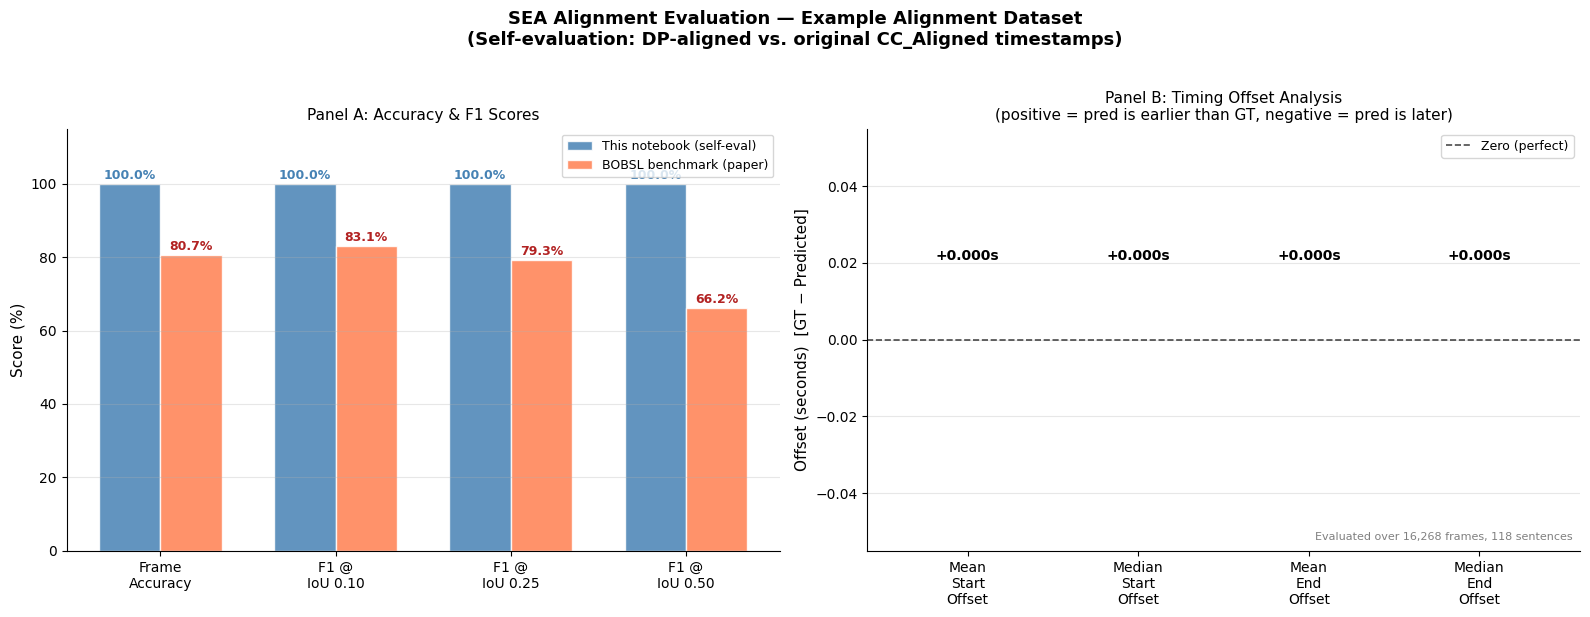

In [15]:
# ── Build the two-panel evaluation figure ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "SEA Alignment Evaluation — Example Alignment Dataset\n"
    "(Self-evaluation: DP-aligned vs. original CC_Aligned timestamps)",
    fontsize=13, fontweight="bold", y=1.02
)

# ── Panel A: F1 Scores and Frame Accuracy ────────────────────────────────────
ax = axes[0]

metric_labels = ["Frame\nAccuracy", "F1 @\nIoU 0.10", "F1 @\nIoU 0.25", "F1 @\nIoU 0.50"]
our_values    = [
    metrics.get('frame_accuracy', 0),
    metrics.get('f1_0.10',        0),
    metrics.get('f1_0.25',        0),
    metrics.get('f1_0.50',        0),
]

# BOBSL benchmark reference (from SEA paper, Segment+Align without embeddings).
bobsl_ref = [80.68, 83.07, 79.32, 66.24]

x = np.arange(len(metric_labels))
width = 0.35

bars_ours  = ax.bar(x - width/2, our_values, width, label="This notebook (self-eval)",
                    color="steelblue", alpha=0.85, edgecolor="white")
bars_bobsl = ax.bar(x + width/2, bobsl_ref,  width, label="BOBSL benchmark (paper)",
                    color="coral",     alpha=0.85, edgecolor="white")

# Add value labels on bars.
for bar in bars_ours:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}%",
            ha="center", va="bottom", fontsize=9, fontweight="bold", color="steelblue")
for bar in bars_bobsl:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}%",
            ha="center", va="bottom", fontsize=9, fontweight="bold", color="firebrick")

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=10)
ax.set_ylabel("Score (%)", fontsize=11)
ax.set_ylim(0, 115)
ax.set_title("Panel A: Accuracy & F1 Scores", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Panel B: Timing Offset Summary ──────────────────────────────────────────
ax = axes[1]

offset_labels = ["Mean\nStart\nOffset", "Median\nStart\nOffset",
                 "Mean\nEnd\nOffset",   "Median\nEnd\nOffset"]
offset_values = [
    metrics.get('mean_start_offset',   0),
    metrics.get('median_start_offset', 0),
    metrics.get('mean_end_offset',     0),
    metrics.get('median_end_offset',   0),
]
colors = ["steelblue" if v >= 0 else "tomato" for v in offset_values]

bars = ax.bar(offset_labels, offset_values, color=colors, alpha=0.85, edgecolor="white")
ax.axhline(0, color="black", linewidth=1.2, linestyle="--", alpha=0.7, label="Zero (perfect)")

for bar, val in zip(bars, offset_values):
    y_pos = val + 0.02 if val >= 0 else val - 0.06
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, f"{val:+.3f}s",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Offset (seconds)  [GT − Predicted]", fontsize=11)
ax.set_title("Panel B: Timing Offset Analysis\n"
             "(positive = pred is earlier than GT, negative = pred is later)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Metadata annotation.
total_f = metrics.get('total_frames', 0)
total_s = metrics.get('total_sentences', 0)
ax.text(0.99, 0.02, f"Evaluated over {total_f:,} frames, {total_s} sentences",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8, color="gray")

plt.tight_layout()

# Save to assets/ for README embedding.
eval_chart_path = ASSETS_DIR / "evaluation_metrics.png"
plt.savefig(eval_chart_path, dpi=150, bbox_inches="tight")
print(f"Evaluation chart saved to: {eval_chart_path}")
plt.show()

---
## Section 8 — Timeline Visualisation

### 8.1 — Three-Track Alignment Timeline

**Design rationale:**

The three horizontal tracks are chosen to reflect the actual data flow through the DP aligner:

1. **Track 0 — Sign Segments** (steel blue): These are the *fixed reference* — the temporal anchors the DP aligner snaps subtitle boundaries to. Each bar is one gloss label from the `Gloss Labeling` tier. The density and regularity of these bars determines the granularity of alignment.

2. **Track 1 — Original CC_Aligned** (tomato red): The raw input subtitle cues. These timestamps reflect when the content was spoken, with a manual but imperfect synchronisation to the video.

3. **Track 2 — DP Aligned** (sea green): The corrected timestamps after the DP algorithm has run. These should have boundaries that coincide with sign segment boundaries.

**What to look for:**
- A subtitle bar in Track 1 that starts before the corresponding sign segment group → the original was too early → DP will shift it right
- Gaps between consecutive bars in Track 1 vs. Track 2: DP alignment can collapse or widen these gaps when it groups sign segments differently
- Alignment of Track 2 bar edges with Track 0 sign segment edges: this is the ideal outcome

**60-second window:** The full video is 11 minutes, too wide to see individual cue details. We zoom into a 60-second window (33s–93s) that contains rich annotation density. You can change `T_START` and `T_END` to explore other regions.

The plot is saved to `assets/alignment_visualization.png` for use in the README and documentation.

C:\Users\USER\AppData\Local\Temp\ipykernel_30616\2857081189.py:73: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.savefig(viz_path, dpi=150, bbox_inches="tight")
C:\Users\USER\AppData\Local\Temp\ipykernel_30616\2857081189.py:73: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  plt.savefig(viz_path, dpi=150, bbox_inches="tight")
C:\Users\USER\AppData\Local\Temp\ipykernel_30616\2857081189.py:73: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.savefig(viz_path, dpi=150, bbox_inches="tight")
C:\Users\USER\AppData\Local\Temp\ipykernel_30616\2857081189.py:73: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from font(s) DejaVu Sans.
  plt.savefig(viz_path, dpi=150, bbox_inches="tight")
C:\Users\USER\AppData\Local\Temp\ipykernel_30616\2857081189.py:73: UserWarning: Glyph 3611 (\N{THAI CHARACTER PO PLA}) missing from font(s) DejaVu Sans.
  plt.sa

Timeline visualisation saved to: c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\assets\alignment_visualization.png


c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Us

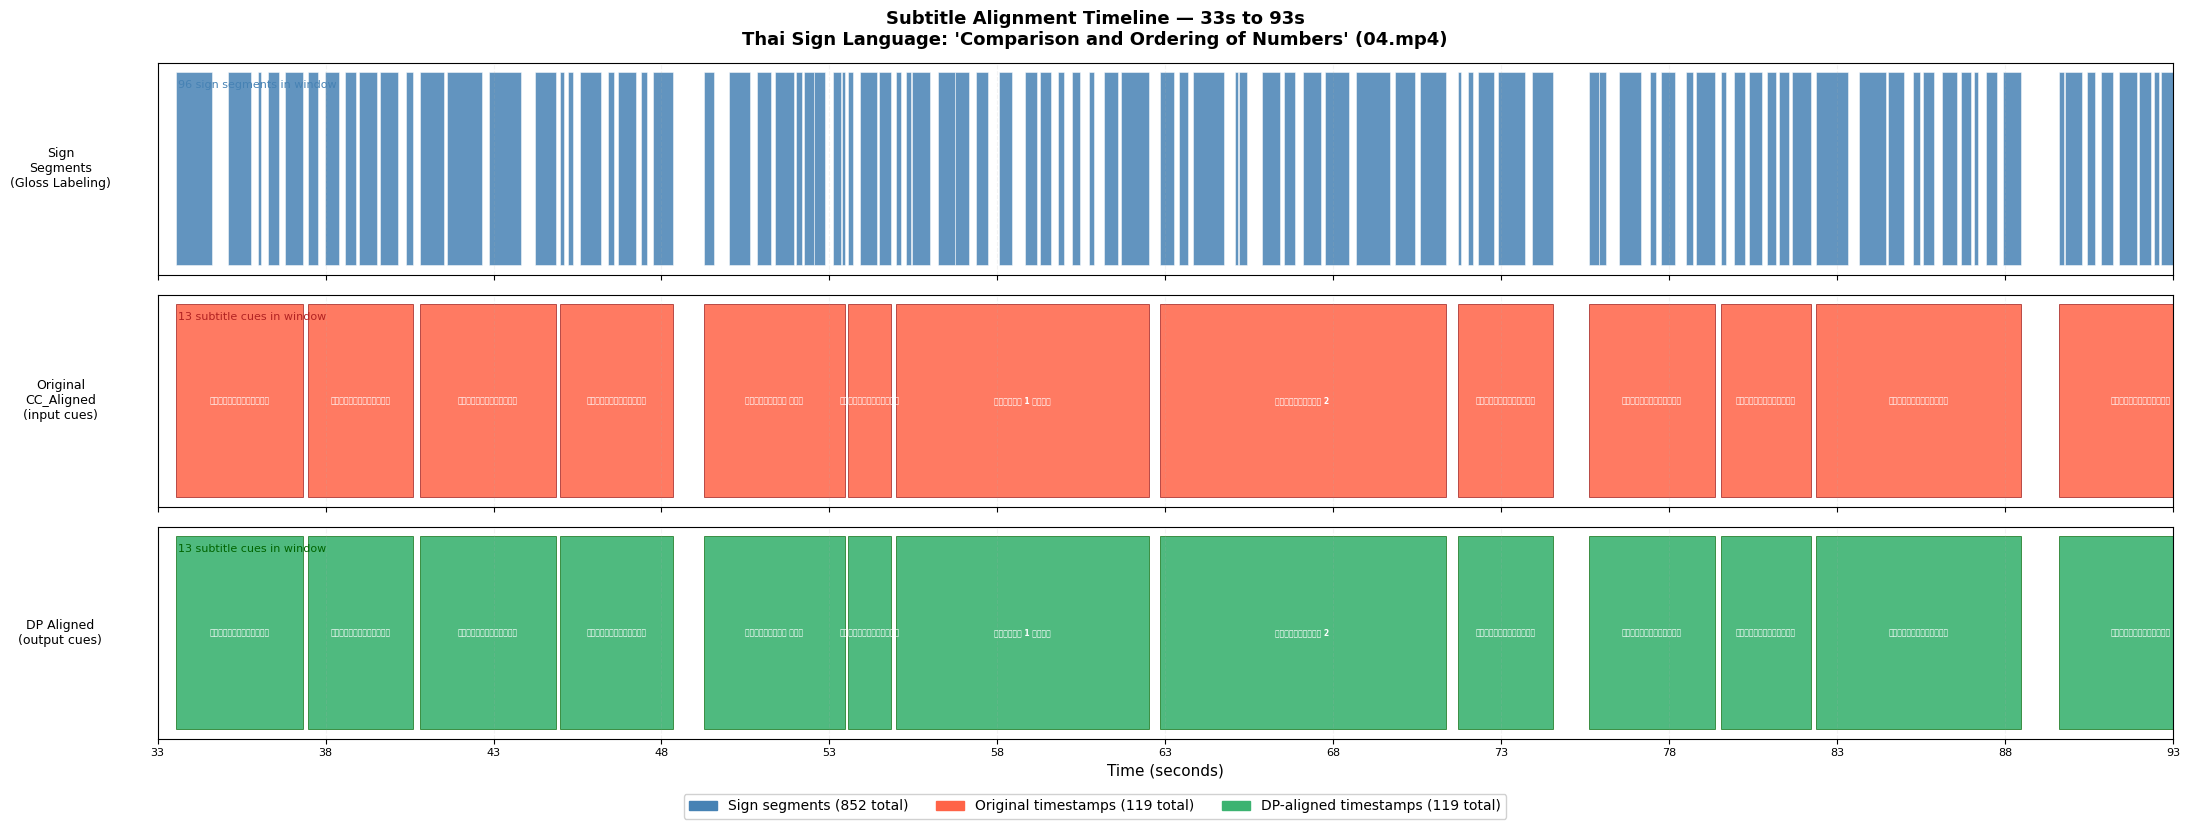

In [16]:
T_START, T_END = 33.0, 93.0   # 60-second inspection window (seconds)

fig, axes = plt.subplots(3, 1, figsize=(22, 8), sharex=True)
fig.suptitle(
    f"Subtitle Alignment Timeline — {T_START:.0f}s to {T_END:.0f}s\n"
    "Thai Sign Language: 'Comparison and Ordering of Numbers' (04.mp4)",
    fontsize=13, fontweight="bold"
)

BAR_H = 0.55

# ── Track 0: Sign Segments (Gloss Labeling tier) ─────────────────────────
ax = axes[0]
ax.set_ylabel("Sign\nSegments\n(Gloss Labeling)", fontsize=9, rotation=0, labelpad=70, va="center")
visible_signs = [s for s in sign_segments if s['end'] >= T_START and s['start'] <= T_END]
for seg in visible_signs:
    ax.barh(0, seg['end'] - seg['start'], left=seg['start'],
            height=BAR_H, color="steelblue", alpha=0.85, edgecolor="white", linewidth=0.4)
ax.set_yticks([])
ax.set_xlim(T_START, T_END)
ax.text(0.01, 0.92, f"{len(visible_signs)} sign segments in window",
        transform=ax.transAxes, fontsize=8, color="steelblue", va="top")

# ── Track 1: Original CC_Aligned subtitles ───────────────────────────────
ax = axes[1]
ax.set_ylabel("Original\nCC_Aligned\n(input cues)", fontsize=9, rotation=0, labelpad=70, va="center")
visible_orig = [c for c in cues_original if c['end'] >= T_START and c['start'] <= T_END]
for cue in visible_orig:
    ax.barh(0, cue['end'] - cue['start'], left=cue['start'],
            height=BAR_H, color="tomato", alpha=0.85, edgecolor="darkred", linewidth=0.5)
    mid_x = max(cue['mid'], T_START + 0.3)
    ax.text(mid_x, 0, cue['text'][:13], ha="center", va="center",
            fontsize=5.5, color="white", fontweight="bold", clip_on=True)
ax.set_yticks([])
ax.text(0.01, 0.92, f"{len(visible_orig)} subtitle cues in window",
        transform=ax.transAxes, fontsize=8, color="firebrick", va="top")

# ── Track 2: DP-aligned subtitles ────────────────────────────────────────
ax = axes[2]
ax.set_ylabel("DP Aligned\n(output cues)", fontsize=9, rotation=0, labelpad=70, va="center")
visible_aligned = [c for c in cues_aligned if c['end'] >= T_START and c['start'] <= T_END]
for cue in visible_aligned:
    ax.barh(0, cue['end'] - cue['start'], left=cue['start'],
            height=BAR_H, color="mediumseagreen", alpha=0.9, edgecolor="darkgreen", linewidth=0.5)
    mid_x = max(cue['mid'], T_START + 0.3)
    ax.text(mid_x, 0, cue['text'][:13], ha="center", va="center",
            fontsize=5.5, color="white", fontweight="bold", clip_on=True)
ax.set_yticks([])
ax.set_xlabel("Time (seconds)", fontsize=11)
ax.text(0.01, 0.92, f"{len(visible_aligned)} subtitle cues in window",
        transform=ax.transAxes, fontsize=8, color="darkgreen", va="top")

# ── Shared tick marks every 5 seconds ────────────────────────────────────
major_ticks = np.arange(T_START, T_END + 1, 5)
for ax in axes:
    ax.set_xticks(major_ticks)
    ax.tick_params(axis='x', which='major', labelsize=8)
    ax.grid(axis='x', alpha=0.15, linestyle='--')

# Legend
legend_patches = [
    mpatches.Patch(color="steelblue",     label=f"Sign segments ({len(sign_segments)} total)"),
    mpatches.Patch(color="tomato",         label=f"Original timestamps ({len(cues_original)} total)"),
    mpatches.Patch(color="mediumseagreen", label=f"DP-aligned timestamps ({len(cues_aligned)} total)"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.04), framealpha=0.9)

plt.tight_layout()

# Save to assets/ for README embedding.
viz_path = ASSETS_DIR / "alignment_visualization.png"
plt.savefig(viz_path, dpi=150, bbox_inches="tight")
print(f"Timeline visualisation saved to: {viz_path}")
plt.show()

---
## Section 9 — Summary and Next Steps

### What this notebook demonstrated

| Step | Input | Function used | Output |
|------|-------|--------------|--------|
| Load EAF | `*.eaf` | `pympi.Elan()` | Tier dictionaries |
| Extract cues | `CC_Aligned` tier | `elan_tier_to_cues()` | 119 subtitle dicts |
| Extract signs | `Gloss Labeling` tier | `elan_tier_to_cues()` | 852 sign-segment dicts |
| JIT warmup | Synthetic data | `dp_align_subtitles_to_signs()` | Compiled cache |
| DP alignment | cues + sign_segments | `dp_align_subtitles_to_signs()` | Corrected timestamps (in-place) |
| Write EAF | `cues_aligned` | `write_updated_eaf()` | `*_updated.eaf` (SUBTITLE_SHIFTED tier) |
| Write VTT | `cues_aligned` | `reconstruct_vtt()` | `aligned_output.vtt` |
| Evaluate | pred VTT + GT VTT | `eval_subtitle_alignment()` | Frame acc., F1@IoU, offsets |
| Visualise metrics | eval string | `parse_eval_string()` + matplotlib | `assets/evaluation_metrics.png` |
| Visualise timeline | cues + signs | matplotlib | `assets/alignment_visualization.png` |

### Generated files
```
data/example_alignment/
├── *_updated.eaf          ← Updated ELAN file (open in ELAN to inspect)
└── aligned_output.vtt     ← Aligned subtitle file

assets/
├── alignment_visualization.png   ← Timeline comparison chart
└── evaluation_metrics.png        ← Quantitative metrics chart
```

### Extending this notebook

**1. Add embedding-based similarity:**
```python
from align_similarity import compute_similarity_matrix
sim_matrix = compute_similarity_matrix(cues, sign_segments,
                                       similarity_measure='text_embedding',
                                       device=DEVICE)
dp_align_subtitles_to_signs(
    cues_aligned, sign_segments,
    similarity_weight=10.0,
    sim_matrix=sim_matrix
)
```
This uses `SentenceTransformer('all-MiniLM-L6-v2')` to compute cosine similarities between subtitle text and gloss text, steering the alignment towards semantically matching pairs.

**2. Full pipeline from raw video:**
```bash
# Stage 0: extract poses
videos_to_poses --format mediapipe --directory data/example_alignment/

# Stage 1: segment
python SEA/segmentation.py --sign-b-threshold 30 --sign-o-threshold 50 \
    --pose_dir data/example_alignment/ --save_dir data/example_segmentation/

# Stage 3: align (using segmentation output, which produces a SIGN tier)
python SEA/align.py --mode=inference --segmentation_dir data/example_segmentation/ ...
```

**3. Parameter tuning:**  
Use `align.py --mode=training --num_search 50` to run a random search over `duration_penalty_weight`, `gap_penalty_weight`, and `max_gap`. The optimal parameters vary significantly between datasets (BOBSL, How2Sign, TSL).

---

📄 **Paper:** [arXiv:2512.08094](https://arxiv.org/abs/2512.08094) — Zifan Jiang et al., *Segment, Embed, and Align: A Universal Recipe for Aligning Subtitles to Signing*, 2025.